# Tips Dataset EDA

Applying all the knowledge behind the notebooks we have previously covered (Data Insights, Data Cleaning and Preprocessing, and Feature Engineering and Selection), we will make a full EDA on various example-Datasets. 

For this notebook, we will run an EDA on the `seaborn` library tips dataset, a dataset with a balanced ammount of numerical and categorical variables, to tackle what EDA's generally look like in datasets similar to these, which are relatively common in real-life scenarios.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import missingno as msno
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import textblob
import spacy
import gensim
import umap.umap_ as umap
from sklearn.feature_selection import SelectKBest, f_regression

## Loading the dataset

First and foremost, we need to load the dataset and do a quick check of its contents, to see if at first sight there is any issues with the import process:

In [38]:
tips = sns.load_dataset('tips')
tips.head()
#tips.info()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


From the official [source link](https://rdrr.io/cran/reshape2/man/tips.html) and as a result of the command `info`, we have 7 features:

- **`total_bill`:** a numerical variable representing the bill on that particular entry in dollars;
- **`tip`:** As the name suggests, a numerical variable representing the tip that was given in dollars;
- **`sex`:** Categorical variable, which represents the gender of the bill payer;
- **`smoker`:** Categorical binary variable, signaling whether there were any smokers in the party;
- **`day`:** Categorical variable that is a truncation of the weekday of the visit;
- **`time`:** Categorical variable that represents which meal the bill refers to;
- **`size`:** Numerical variable representing the size of the party

## Initial Data Inspection

Now we can run some initial observations to get some insights on this dataset:

In [39]:
print(tips.describe())

       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [40]:
# Check for missing values
print(tips.isnull().sum())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [41]:
Z_bill = stats.zscore(tips['total_bill'])
Z_tip = stats.zscore(tips['tip'])

outliers_bill = tips[(Z_bill < -3) | (Z_bill > 3)]
outliers_tip = tips[(Z_tip < -3) | (Z_tip > 3)]

print("Estimated outliers in total_bill: ", outliers_bill)
print("Estimated outliers in tip: ", outliers_tip)

Estimated outliers in total_bill:       total_bill    tip   sex smoker  day    time  size
59        48.27   6.73  Male     No  Sat  Dinner     4
156       48.17   5.00  Male     No  Sun  Dinner     6
170       50.81  10.00  Male    Yes  Sat  Dinner     3
212       48.33   9.00  Male     No  Sat  Dinner     4
Estimated outliers in tip:       total_bill    tip   sex smoker  day    time  size
23        39.42   7.58  Male     No  Sat  Dinner     4
170       50.81  10.00  Male    Yes  Sat  Dinner     3
212       48.33   9.00  Male     No  Sat  Dinner     4


There is no need for imputation due to missing values, which is good. But keep in mind that usually the case is that there are going to be missing values that need to be addressed. When talking about outliers, it makes sense to run an analysis on the bill and tip columns. The results show that using the `z-score evaluation` gives 4 outliers in the `bill` column and 3 outliers in the `tip` column, where there are 2 that intersect. Due to the overall nature of this dataset and the fact that it is few examples, it will be more fruitful to maintain these outliers in the dataset.

## Univariate Analysis

Now we run some more detailed observations on the numerical and categorical data:

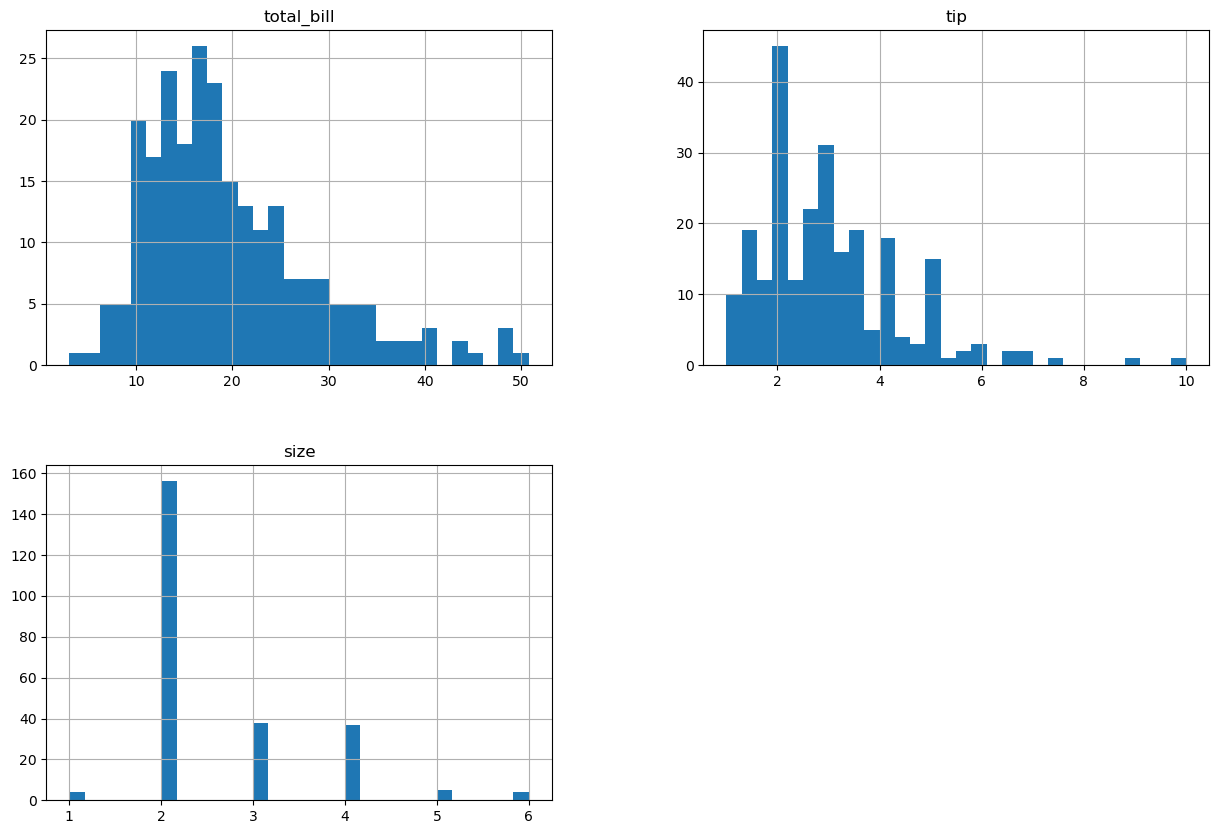

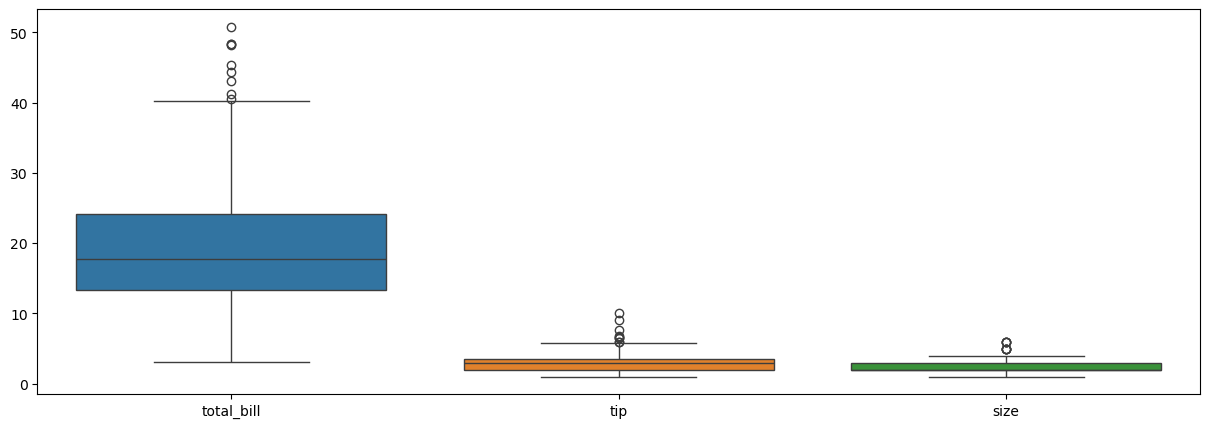

In [42]:
# Histograms for numerical features
tips.hist(bins=30, figsize=(15, 10))
plt.show()

# Boxplots for numerical features
plt.figure(figsize=(15, 5))
sns.boxplot(data=tips.select_dtypes(include=['float64', 'int64']))
plt.show()

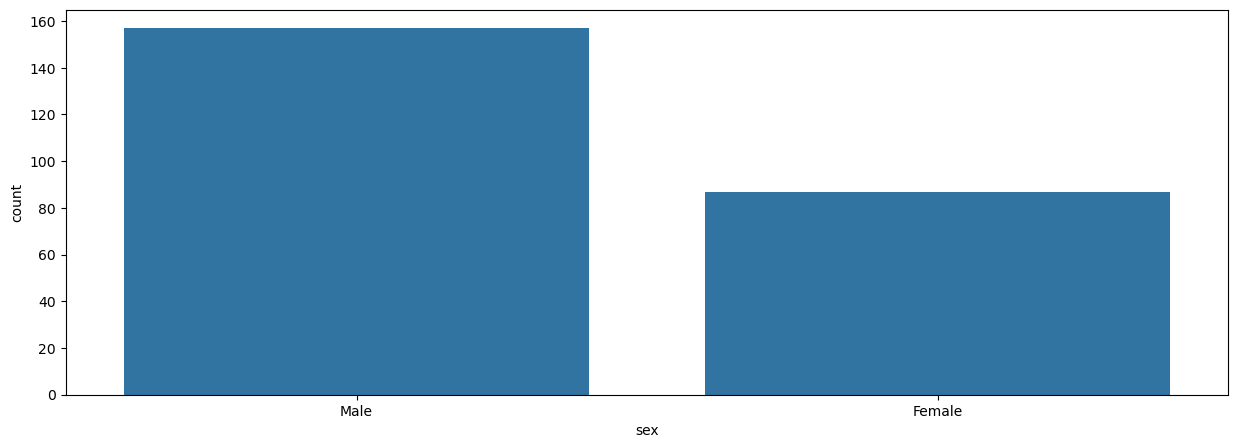

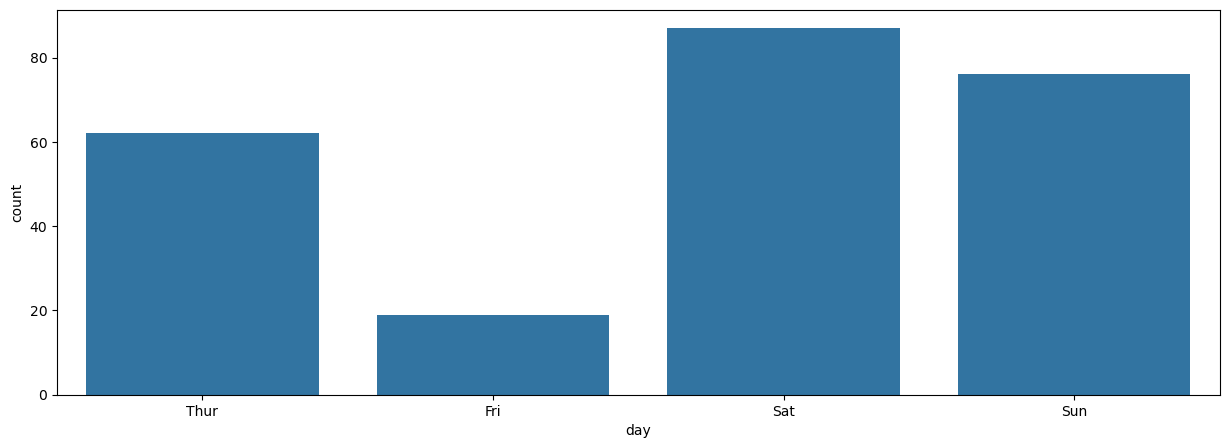

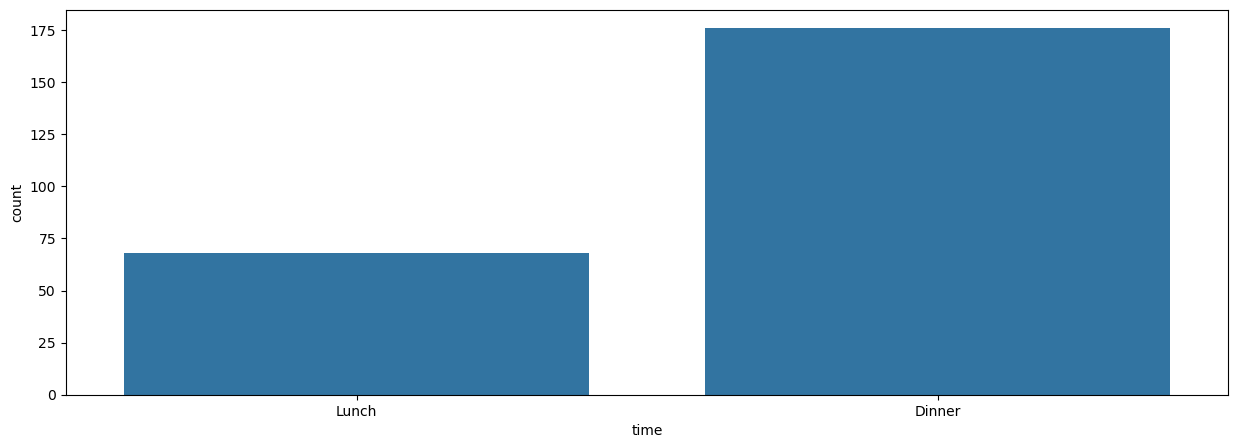

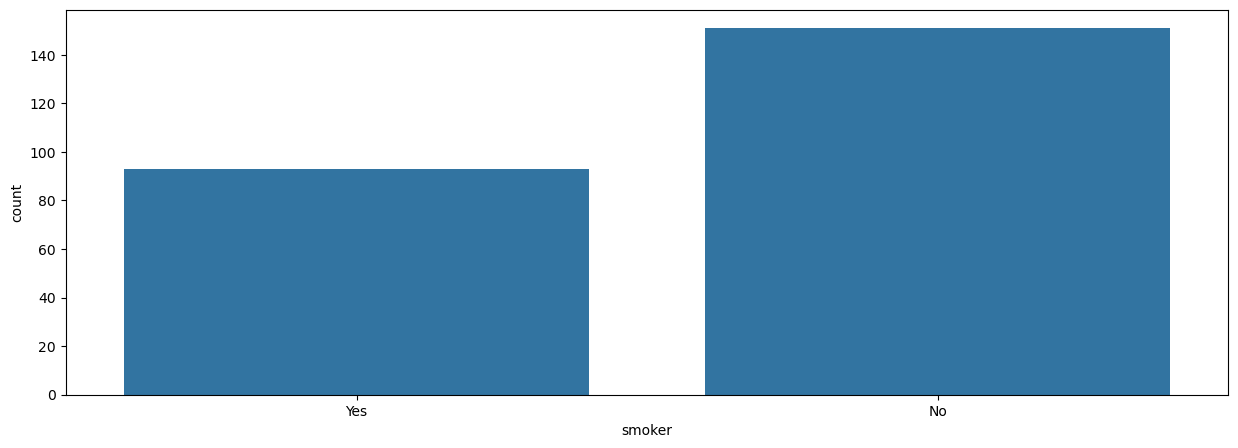

In [43]:
# Count plots for categorical features
plt.figure(figsize=(15, 5))
sns.countplot(data=tips, x='sex')
plt.show()

plt.figure(figsize=(15, 5))
sns.countplot(data=tips, x='day')
plt.show()

plt.figure(figsize=(15, 5))
sns.countplot(data=tips, x='time')
plt.show()

plt.figure(figsize=(15, 5))
sns.countplot(data=tips, x='smoker')
plt.show()

There is no substantial imbalance, ate least not at fisrt sight. To accurately investigate this phenomenon, we can try the approach of seeing the ratio of each label per categorical variable:

In [44]:
for col in ['sex', 'day', 'time', 'smoker']:
    print(f"Distribution of {col}:")
    print(tips[col].value_counts(normalize=True) * 100)
    print()

Distribution of sex:
sex
Male      64.344262
Female    35.655738
Name: proportion, dtype: float64

Distribution of day:
day
Sat     35.655738
Sun     31.147541
Thur    25.409836
Fri      7.786885
Name: proportion, dtype: float64

Distribution of time:
time
Dinner    72.131148
Lunch     27.868852
Name: proportion, dtype: float64

Distribution of smoker:
smoker
No     61.885246
Yes    38.114754
Name: proportion, dtype: float64



There is generally a mild imbalance on the categorical variables, and 2 cases when the imbalance is moderate (on the features `time` and `sex`). But since those particular cases the proportion between the categories is not too high (only approximately 2.5:1 and 1.78:1, respectively), the appropriate approach might be to use class weighting when it comes to generate the predictive model on this dataset.

## Multivariate Analysis

After analysing each feature individually, we can see their behaviour when grouped. To start off, we need to encode the categorical features. Since all of them are evidently `nominal`, the correct method, although increasing the dimensionality of the dataset, is using `One-Hot Encoding`:

In [45]:
# One-hot encoding for categorical features
tips_encoded = pd.get_dummies(tips, drop_first=True)
print(tips_encoded.head())

   total_bill   tip  size  sex_Female  smoker_No  day_Fri  day_Sat  day_Sun  \
0       16.99  1.01     2        True       True    False    False     True   
1       10.34  1.66     3       False       True    False    False     True   
2       21.01  3.50     3       False       True    False    False     True   
3       23.68  3.31     2       False       True    False    False     True   
4       24.59  3.61     4        True       True    False    False     True   

   time_Dinner  
0         True  
1         True  
2         True  
3         True  
4         True  


After encoding the categorical features, we proceed to the scaling of the numerical features. To simplify this task, and setting the dataset up for a potential dimensional reduction technique to reduce the increased one introduced by the encoding, we use the `Standardization` method, while avoiding the target feature column, `tip`: 

In [46]:
# Separate features and target
X = tips_encoded.drop(columns=['tip'])  # Features (exclude the target)
y = tips_encoded['tip']  # Target (tip column)

# Standard scaling for numerical features (excluding the target)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.select_dtypes(include=['float64', 'int64']))
X_scaled = pd.DataFrame(X_scaled, columns=X.select_dtypes(include=['float64', 'int64']).columns)

# Add back the categorical features (if any) that were not scaled
X_scaled = pd.concat([X_scaled, X.select_dtypes(exclude=['float64', 'int64'])], axis=1)

# Combine scaled features and target (optional)
tips_scaled = pd.concat([X_scaled, y], axis=1)

print(tips_scaled.head())

   total_bill      size  sex_Female  smoker_No  day_Fri  day_Sat  day_Sun  \
0   -0.314711 -0.600193        True       True    False    False     True   
1   -1.063235  0.453383       False       True    False    False     True   
2    0.137780  0.453383       False       True    False    False     True   
3    0.438315 -0.600193       False       True    False    False     True   
4    0.540745  1.506958        True       True    False    False     True   

   time_Dinner   tip  
0         True  1.01  
1         True  1.66  
2         True  3.50  
3         True  3.31  
4         True  3.61  


After running these changes, we can select which features are the best to predict the `tip` column's value:

In [47]:
# SelectKBest for feature selection
X = tips_scaled
y = tips_encoded['tip']
selector = SelectKBest(score_func=f_regression, k=5)
X_new = selector.fit_transform(X, y)
print('The features with the highest scores are:', X.columns[selector.get_support()])

The features with the highest scores are: Index(['total_bill', 'size', 'sex_Female', 'day_Sun', 'time_Dinner'], dtype='object')


Now we can also apply dimentional reduction techniques (`UMAP`, for example), to run more advanced visualisations on this dataset:

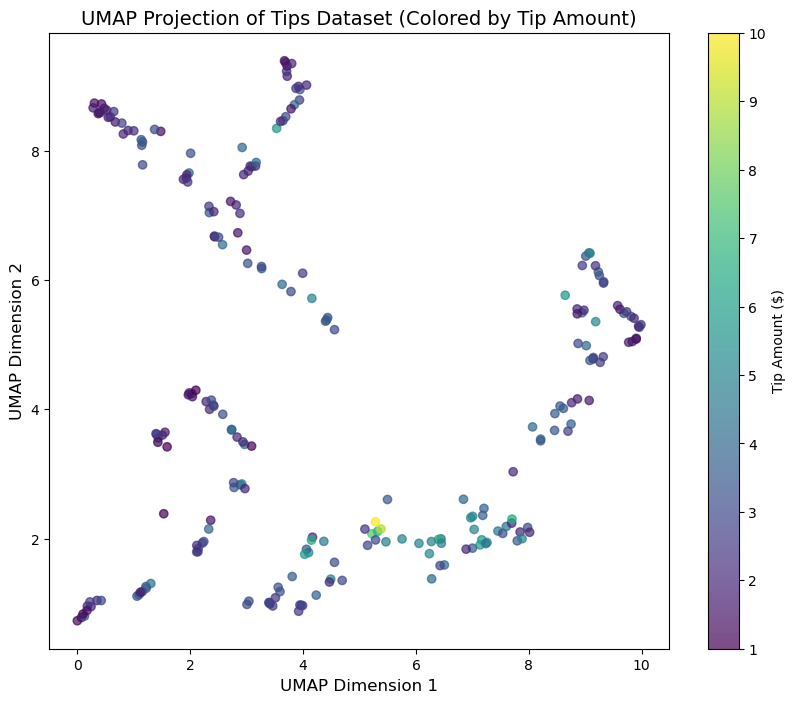

In [48]:
# UMAP for dimensionality reduction
reducer = umap.UMAP(random_state=42)  # Initialize UMAP reducer with a random seed for reproducibility
embedding = reducer.fit_transform(X_scaled)  # Reduce the data to 2D

# Create the scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=tips_encoded['tip'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Tip Amount ($)')  # Add a colorbar with a label

# Add labels and title
plt.title('UMAP Projection of Tips Dataset (Colored by Tip Amount)', fontsize=14)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)

# Show the plot
plt.show()

Since the technique is **Non-Linear** and **focuses on relationships** (UMAP prioritizes preserving the relationships (distances) between data points), the UMAP dimensions are not directly interpretable in the same way as the original features. We can try to see if the dimensions are more strongly influenced by what features, by adding the respective values to new columns and try to see the correlation matrix:

In [49]:
# Create a DataFrame with UMAP dimensions and original features
umap_df = pd.DataFrame(embedding, columns=['UMAP_1', 'UMAP_2'])
original_features = X_scaled.select_dtypes(include=['float64', 'int64'])  # Numerical features only

# Combine UMAP dimensions with original features
combined_df = pd.concat([umap_df, original_features], axis=1)

# Calculate correlation matrix
correlation_matrix = combined_df.corr()

# Display correlation between UMAP dimensions and original features
print(correlation_matrix[['UMAP_1', 'UMAP_2']].drop(['UMAP_1', 'UMAP_2']))

              UMAP_1    UMAP_2
total_bill  0.238695 -0.398877
size        0.342136 -0.518487
